In [2]:
import pandas as pd

file_path = "/Users/Nisrin Fariss Lamine/Downloads/tfm/BIOGRID-ALL-5.0.254.tab3.txt"
df = pd.read_csv(file_path, sep='\t')

df.head()
print("Dimensiones:", df.shape)
print("Columnas:", df.columns)

C:\Users\Nisrin Fariss Lamine\AppData\Local\Temp\ipykernel_9820\2481409173.py:4: DtypeWarning: Columns (1,2,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, sep='\t')


Dimensiones: (2835229, 37)
Columnas: Index(['#BioGRID Interaction ID', 'Entrez Gene Interactor A',
       'Entrez Gene Interactor B', 'BioGRID ID Interactor A',
       'BioGRID ID Interactor B', 'Systematic Name Interactor A',
       'Systematic Name Interactor B', 'Official Symbol Interactor A',
       'Official Symbol Interactor B', 'Synonyms Interactor A',
       'Synonyms Interactor B', 'Experimental System',
       'Experimental System Type', 'Author', 'Publication Source',
       'Organism ID Interactor A', 'Organism ID Interactor B', 'Throughput',
       'Score', 'Modification', 'Qualifications', 'Tags', 'Source Database',
       'SWISS-PROT Accessions Interactor A', 'TREMBL Accessions Interactor A',
       'REFSEQ Accessions Interactor A', 'SWISS-PROT Accessions Interactor B',
       'TREMBL Accessions Interactor B', 'REFSEQ Accessions Interactor B',
       'Ontology Term IDs', 'Ontology Term Names', 'Ontology Term Categories',
       'Ontology Term Qualifier IDs', 'Ontology Te

In [3]:
df_human = df[
    (df['Organism ID Interactor A'] == 9606) &
    (df['Organism ID Interactor B'] == 9606) &
    (df['Experimental System Type'] == 'physical')
]

df_edges = df_human[[
    'SWISS-PROT Accessions Interactor A',
    'SWISS-PROT Accessions Interactor B'
]].dropna()

# limpiar múltiples IDs
df_edges['source'] = df_edges['SWISS-PROT Accessions Interactor A'].apply(lambda x: x.split('|')[0])
df_edges['target'] = df_edges['SWISS-PROT Accessions Interactor B'].apply(lambda x: x.split('|')[0])

df_edges = df_edges[['source', 'target']].drop_duplicates()

df_edges.head()


,source,target
0,P45985,Q14315
1,Q86TC9,P35609
2,Q04771,P49354
3,P23769,P29590
4,P15927,P40763


In [4]:
df_nodes_A = df_human[[
    'SWISS-PROT Accessions Interactor A',
    'Official Symbol Interactor A',
    'Entrez Gene Interactor A'
]].rename(columns={
    'SWISS-PROT Accessions Interactor A': 'uniprot',
    'Official Symbol Interactor A': 'symbol',
    'Entrez Gene Interactor A': 'entrez'
})

df_nodes_B = df_human[[
    'SWISS-PROT Accessions Interactor B',
    'Official Symbol Interactor B',
    'Entrez Gene Interactor B'
]].rename(columns={
    'SWISS-PROT Accessions Interactor B': 'uniprot',
    'Official Symbol Interactor B': 'symbol',
    'Entrez Gene Interactor B': 'entrez'
})

df_nodes = pd.concat([df_nodes_A, df_nodes_B]).drop_duplicates()
df_nodes

,uniprot,symbol,entrez
0,P45985,MAP2K4,6416
1,Q86TC9,MYPN,84665
2,Q04771,ACVR1,90
3,P23769,GATA2,2624
4,P15927,RPA2,6118
...,...,...,...
2834900,-,TRAF3IP2-AS1,643749
2834903,-,LINC01122,400955
2834910,-,LINC01534,101927621
2834917,Q5K4E3,PRSS36,146547


In [5]:
proteins = df_nodes[df_nodes['uniprot'] != '-']['uniprot'].unique()
print(f"Número total de proteínas únicas: {len(proteins)}")
print("Primeras 10 proteínas:\n", proteins[:10])

Número total de proteínas únicas: 18040
Primeras 10 proteínas:
 ['P45985' 'Q86TC9' 'Q04771' 'P23769' 'P15927' 'P84077' 'P61204' 'Q8IZH2'
 'P05067' 'P51693']


In [6]:
import networkx as nx

G = nx.from_pandas_edgelist(df_edges, 'source', 'target')

print("Nodos:", G.number_of_nodes())
print("Aristas:", G.number_of_edges())

Nodos: 18027
Aristas: 900466


In [7]:
components = sorted(nx.connected_components(G), key=len, reverse=True)
G = G.subgraph(components[0]).copy()


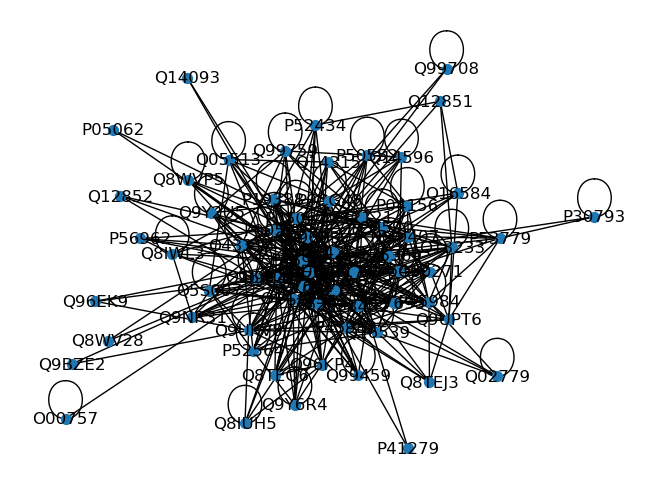

In [8]:
protein = "P45985"  # ejemplo
neighbors = list(G.neighbors(protein))

sub_nodes = neighbors + [protein]
subG = G.subgraph(sub_nodes)

nx.draw(subG, with_labels=True, node_size=50)

In [ ]:
'''import xml.etree.ElementTree as ET
import pandas as pd

file_path = "/Users/Nisrin Fariss Lamine/Downloads/tfm/full_database.xml"

ns = '{http://www.drugbank.ca}'

data = []

# 🔥 iterparse = mucho más rápido y eficiente
for event, elem in ET.iterparse(file_path, events=("end",)):
    
    if elem.tag == ns + "drug":
        
        # ---- Filtrar approved ----
        approved = False
        for group in elem.findall(ns + "groups/" + ns + "group"):
            if group.text == "approved":
                approved = True
                break
        
        if not approved:
            elem.clear()
            continue
        
        # ---- ID ----
        drugbank_id = None
        for db_id in elem.findall(ns + "drugbank-id"):
            if db_id.get("primary") == "true":
                drugbank_id = db_id.text
        
        # ---- Nombre ----
        name_elem = elem.find(ns + "name")
        name = name_elem.text if name_elem is not None else None
        
        # ---- Targets ----
        for target in elem.findall(ns + "targets/" + ns + "target"):
            
            organism = target.find(ns + "organism")
            
            if organism is not None and organism.text == "Humans":
                
                polypeptide = target.find(ns + "polypeptide")
                
                if polypeptide is not None:
                    uniprot_id = polypeptide.get("id")
                    
                    if uniprot_id:
                        data.append([drugbank_id, name, uniprot_id])
        
        # 🔥 MUY IMPORTANTE: liberar memoria
        elem.clear()

# ---- Crear DataFrame ----
df_drug_clean = pd.DataFrame(
    data,
    columns=["DrugBank_ID", "Drug_Name", "UniProt_ID"]
).drop_duplicates()

# ---- Guardar CSV ----
df_drug_clean.to_csv(
    "/Users/Nisrin Fariss Lamine/Downloads/tfm/drugbank_targets_clean.csv",
    index=False
)

print("CSV creado ✅")
print(df_drug_clean.shape)'''


In [9]:
import pandas as pd
import networkx as nx

df_drug_clean = pd.read_csv("drugbank_targets_clean.csv")

In [10]:
drugbank_targets = set(df_drug_clean['UniProt_ID'])

print("Proteínas diana en DrugBank:", len(drugbank_targets))

Proteínas diana en DrugBank: 2277


In [11]:

interactome_proteins = set(G.nodes())

print("Proteínas en el interactoma:", len(interactome_proteins))

Proteínas en el interactoma: 18023


In [12]:
overlap = interactome_proteins.intersection(drugbank_targets)

print("Proteínas en común:", len(overlap))

print("Cobertura DrugBank → interactoma:",
      round(len(overlap) / len(drugbank_targets) * 100, 2), "%")

Proteínas en común: 2216
Cobertura DrugBank → interactoma: 97.32 %


In [13]:
df_drug_interactome = df_drug_clean[
    df_drug_clean['UniProt_ID'].isin(interactome_proteins)
]

print("Relaciones utilizables:", df_drug_interactome.shape)

Relaciones utilizables: (9210, 3)


In [14]:
B = nx.Graph()

edges = list(zip(
    df_drug_interactome['DrugBank_ID'],
    df_drug_interactome['UniProt_ID']
))

B.add_edges_from(edges)

print("Nodos:", B.number_of_nodes())
print("Aristas:", B.number_of_edges())

Nodos: 4548
Aristas: 9210


In [15]:
drug_targets = (
    df_drug_interactome
    .groupby('DrugBank_ID')['UniProt_ID']
    .apply(set)
    .to_dict()
)

print("Número de fármacos:", len(drug_targets))

Número de fármacos: 2332


In [17]:
disease_proteins = {
    "P38398",  # BRCA1
    "P04637",  # TP53
    "P00533",  # EGFR
}

dist_to_disease = {}

for source in disease_proteins:
    
    lengths = nx.single_source_shortest_path_length(G, source)
    
    for node, dist in lengths.items():
        
        if node not in dist_to_disease:
            dist_to_disease[node] = dist
        else:
            dist_to_disease[node] = min(dist_to_disease[node], dist)

In [ ]:


dist_to_disease = {}

for source in disease_proteins:
    
    lengths = nx.single_source_shortest_path_length(G, source)
    
    for node, dist in lengths.items():
        
        if node not in dist_to_disease:
            dist_to_disease[node] = dist
        else:
            dist_to_disease[node] = min(dist_to_disease[node], dist)

In [20]:
print(len(dist_to_disease))

18023


In [21]:
list(dist_to_disease.items())[:5]

[('P38398', 0), ('Q14315', 1), ('P29590', 1), ('P15927', 1), ('P04075', 1)]

0 → proteína de enfermedad
1 → vecina directa
2 → a dos pasos

In [22]:
def network_proximity(targets, dist_to_disease):

    dists = [
        dist_to_disease.get(t, float("inf"))
        for t in targets
    ]

    if len(dists) == 0:
        return None

    return sum(dists) / len(dists)

In [23]:
drug_scores = {}

for drug, targets in drug_targets.items():

    valid_targets = targets.intersection(interactome_proteins)

    if len(valid_targets) == 0:
        continue

    score = network_proximity(valid_targets, dist_to_disease)

    if score is not None:
        drug_scores[drug] = score

In [24]:
ranking = pd.DataFrame(
    drug_scores.items(),
    columns=["DrugBank_ID", "proximity"]
).sort_values("proximity")

ranking.head(20)

,DrugBank_ID,proximity
1677,DB09330,0.000000
2259,DB16390,0.000000
2246,DB16216,0.000000
1023,DB01269,0.000000
1715,DB09559,0.000000
255,DB00317,0.000000
429,DB00530,0.500000
2331,DB21667,0.500000
1530,DB08916,0.666667
1874,DB11963,0.666667


In [25]:
drug_names = df_drug_clean[['DrugBank_ID', 'Drug_Name']].drop_duplicates()

ranking = ranking.merge(
    drug_names,
    on="DrugBank_ID",
    how="left"
)

ranking.head(20)

,DrugBank_ID,proximity,Drug_Name
0,DB09330,0.000000,Osimertinib
1,DB16390,0.000000,Mobocertinib
2,DB16216,0.000000,Lazertinib
3,DB01269,0.000000,Panitumumab
4,DB09559,0.000000,Necitumumab
5,DB00317,0.000000,Gefitinib
6,DB00530,0.500000,Erlotinib
7,DB21667,0.500000,Sevabertinib
8,DB08916,0.666667,Afatinib
9,DB11963,0.666667,Dacomitinib


In [26]:
known_drugs = {"DB00843", "DB01043"}  # ejemplo

ranking['is_known'] = ranking['DrugBank_ID'].isin(known_drugs)

ranking.head(20)

,DrugBank_ID,proximity,Drug_Name,is_known
0,DB09330,0.000000,Osimertinib,False
1,DB16390,0.000000,Mobocertinib,False
2,DB16216,0.000000,Lazertinib,False
3,DB01269,0.000000,Panitumumab,False
4,DB09559,0.000000,Necitumumab,False
5,DB00317,0.000000,Gefitinib,False
6,DB00530,0.500000,Erlotinib,False
7,DB21667,0.500000,Sevabertinib,False
8,DB08916,0.666667,Afatinib,False
9,DB11963,0.666667,Dacomitinib,False


In [28]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
streamlit hello

SyntaxError: invalid syntax (2773187961.py, line 1)

In [27]:
import streamlit as st
import pandas as pd
import networkx as nx

st.title("Drug Repurposing App")

# -------- Cargar datos --------
@st.cache_data
def load_data():
    df = pd.read_csv("drugbank_targets_clean.csv")
    G = nx.read_edgelist("interactome_edges.csv")
    return df, G

df, G = load_data()

# -------- Input --------
disease_input = st.text_input("Introduce enfermedad (ej: Alzheimer)")

if disease_input:

    # Aquí usarías DisGeNET local
    df_dis = pd.read_csv("disgenet.tsv", sep="\t")

    df_disease = df_dis[
        df_dis['diseaseName'].str.lower().str.contains(disease_input.lower())
    ]

    df_disease = df_disease[df_disease['score'] > 0.3]

    genes = set(df_disease['geneSymbol'])

    # ⚠️ adaptar según ID (UniProt o gene symbol)
    disease_proteins = genes.intersection(G.nodes())

    st.write("Número de proteínas:", len(disease_proteins))

    # -------- Distancias --------
    dist_to_disease = {}

    for source in disease_proteins:
        lengths = nx.single_source_shortest_path_length(G, source)
        for node, dist in lengths.items():
            if node not in dist_to_disease:
                dist_to_disease[node] = dist
            else:
                dist_to_disease[node] = min(dist_to_disease[node], dist)

    # -------- Drug targets --------
    drug_targets = (
        df.groupby('DrugBank_ID')['UniProt_ID']
        .apply(set)
        .to_dict()
    )

    def proximity(targets):
        dists = [dist_to_disease.get(t, float("inf")) for t in targets]
        return sum(dists) / len(dists)

    results = []

    for drug, targets in drug_targets.items():
        score = proximity(targets)
        results.append((drug, score))

    ranking = pd.DataFrame(results, columns=["Drug", "Score"])
    ranking = ranking.sort_values("Score")

    st.dataframe(ranking.head(20))

2026-04-24 14:42:09.833 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-24 14:42:10.145 
  command:

    streamlit run C:\Users\Nisrin Fariss Lamine\anaconda3\lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-04-24 14:42:10.146 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-24 14:42:10.147 No runtime found, using MemoryCacheStorageManager
2026-04-24 14:42:10.151 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-24 14:42:10.151 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-24 14:42:10.152 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-24 14:42:10.153 No runtime found, using MemoryCacheStorageManager
2026-04-24

FileNotFoundError: [Errno 2] No such file or directory: 'interactome_edges.csv'

In [ ]:
overlap = interactome_proteins.intersection(drugbank_targets)

print("Proteínas en común:", len(overlap))

In [ ]:
print("Porcentaje de dianas cubiertas por el interactoma:",
      round(len(overlap) / len(drugbank_targets) * 100, 2), "%")

print("Porcentaje del interactoma que son dianas farmacológicas:",
      round(len(overlap) / len(interactome_proteins) * 100, 2), "%")

In [ ]:
df['Experimental System Type'].value_counts()


In [ ]:
df_human.shape

In [ ]:
df_drug_interactome = df_drug_clean[
    df_drug_clean['UniProt_ID'].isin(interactome_proteins)
]

print("Relaciones fármaco–proteína utilizables:", df_drug_interactome.shape)

In [ ]:
print("Número de fármacos:", df_drug_interactome['DrugBank_ID'].nunique())#Esto te dice cuántos fármacos tienen al menos una diana en el interactoma.

In [ ]:
import networkx as nx

B = nx.Graph()

for _, row in df_drug_interactome.iterrows():
    
    drug = row['DrugBank_ID']
    protein = row['UniProt_ID']
    
    B.add_node(drug, type='drug')
    B.add_node(protein, type='protein')
    
    B.add_edge(drug, protein)
    

In [ ]:
print("Nodos:", B.number_of_nodes())
print("Aristas:", B.number_of_edges())

In [ ]:
drug_degree = [
    B.degree(n) for n,d in B.nodes(data=True) if d['type']=='drug'
]

import matplotlib.pyplot as plt

plt.hist(drug_degree, bins=30)
plt.xlabel("Número de targets")
plt.ylabel("Número de fármacos")
plt.title("Distribución de targets por fármaco")
plt.show()

In [ ]:
drug_targets = (
    df_drug_interactome
    .groupby('DrugBank_ID')['UniProt_ID']
    .apply(set)
    .to_dict()
)

len(drug_targets)

In [ ]:
drug_targets["DB01050"]#q proteina ataca

In [ ]:
import random

# coger 500 nodos aleatorios
sample_nodes = random.sample(list(G.nodes()), 500)

subG = G.subgraph(sample_nodes).copy()

print(subG.number_of_nodes(), subG.number_of_edges())

In [ ]:
disease_proteins = set(random.sample(list(subG.nodes()), 5))

print("Proteínas de enfermedad:", disease_proteins)

In [ ]:
sample_drugs = list(drug_targets.keys())[:50]

drug_targets_small = {
    drug: targets.intersection(subG.nodes())
    for drug, targets in drug_targets.items()
    if drug in sample_drugs
}

In [ ]:
shortest_paths = dict(nx.all_pairs_shortest_path_length(subG))

In [ ]:
def network_proximity(drug_targets, disease_proteins, shortest_paths):

    distances = []

    for target in drug_targets:

        if target not in shortest_paths:
            continue

        min_dist = min(
            shortest_paths[target].get(dp, float("inf"))
            for dp in disease_proteins
        )

        distances.append(min_dist)

    if len(distances) == 0:
        return None

    return sum(distances) / len(distances)

In [ ]:
drug_scores = {}

for drug, targets in drug_targets_small.items():
    
    score = network_proximity(targets, disease_proteins, shortest_paths)
    
    if score is not None:
        drug_scores[drug] = score

In [ ]:

ranking = pd.DataFrame(
    drug_scores.items(),
    columns=["Drug", "proximity"]
).sort_values("proximity")

ranking.head()